In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from glob import glob
from photutils import aperture
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import math
from astropy.time import Time
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit


In [2]:
# datapath
datapath = '/home/lmenotti/ASTR136/lab1_astr136/data'
#lists of files, seperating by data type. grabbing files and organizing them using glob. all are reduced images except science_list and cal4_raw, to get headers
bias_list =  glob(f'{datapath}/fridaybias.fits')+glob(f'{datapath}/master_bias.fits')
dflat_list =  glob(f'{datapath}/fridaydome.fits')+glob(f'{datapath}/dome_flat.fits')
sflat_list =  glob(f'{datapath}/fridaysky.fits')+glob(f'{datapath}/sky_flat.fits')
# calibration stars
cal1_path = glob(f'{datapath}/cal1.fits')
cal2_path  = glob(f'{datapath}/cal2.fits')
# use this one
cal4_path = glob(f'{datapath}/fridaycal4.fits')+glob(f'{datapath}/cal4.fits') 
# raw cal images to get headers
cal4_raw_path = glob(f'{datapath}/d16[4-8]x.fits')+glob(f'{datapath}/d18[7-9].fits')+glob(f'{datapath}/d19[0-1].fits')
# science images, not reduced
science_list = glob(f'{datapath}/d169x.fits') + glob(f'{datapath}/d17[0-3]x.fits') + glob(f'{datapath}/d20[4-8]x.fits')+glob(f'{datapath}/d229x.fits') + glob(f'{datapath}/d23[0-3]x.fits')+ glob(f'{datapath}/d249x.fits')+ glob(f'{datapath}/d25[0-3]x.fits')+glob(f'{datapath}/d19[2-6].fits') + glob(f'{datapath}/d23[3-7].fits') + glob(f'{datapath}/d25[8-9].fits')+glob(f'{datapath}/d26[0-2].fits') + glob(f'{datapath}/d27[8-9].fits')+ glob(f'{datapath}/d28[0-2].fits')
# reduced science images
science_reduced_list = glob(f'{datapath}/fridayj1122.fits')+glob(f'{datapath}/j1122.fits')

In [3]:
bias=[]
with fits.open(bias_list[0]) as hdul:
    bias.append(hdul[0].data)
with fits.open(bias_list[1]) as hdul:
    bias.append(hdul[0].data)
dflat=[]
with fits.open(dflat_list[0]) as hdul:
    dflat.append(hdul[0].data)
with fits.open(dflat_list[1]) as hdul:
    dflat.append(hdul[0].data)
sflat=[]
with fits.open(sflat_list[0]) as hdul:
    sflat.append(hdul[0].data)
with fits.open(sflat_list[1]) as hdul:
    sflat.append(hdul[0].data)

cal4=[]
with fits.open(cal4_path[0]) as hdul:
    cal4.append(hdul[0].data)
with fits.open(cal4_path[1]) as hdul:
    cal4.append(hdul[0].data)
# just for testing purposes
with fits.open(cal1_path[0]) as hdul:
    cal1=hdul[0].data
with fits.open(cal2_path[0]) as hdul:
    cal2=hdul[0].data

# defining list that will contain all the sci images
sci_data_list = []
sci_header_list = []
# iterating through all 10 sci images
for i in range(len(science_list)):
    # open the sci image that will be added to the list
    with fits.open(science_list[i]) as hdul:
        # appened the sci to the list
        data = hdul[0].data
        header= hdul[0].header
        sci_data_list.append(data)
        sci_header_list.append(header)

In [4]:
cal4_header =[]
cal4_raw =[]
# grabbing all headers from the raw files, and data, and adding to lists for later
index =0
for i in cal4_raw_path:
    with fits.open(cal4_raw_path[index]) as hdul:
        cal4_header.append(hdul[0].header)
        cal4_raw.append(hdul[0].data)
    index = index+1
    if index > 9:
        break

In [5]:
print(science_reduced_list[0])

/home/lmenotti/ASTR136/lab1_astr136/data/fridayj1122.fits


In [6]:
# opening all reduced science images, adding to list
science_reduced =[]
with fits.open(science_reduced_list[0]) as hdul:
    science_reduced.append(hdul[0].data)
with fits.open(science_reduced_list[1]) as hdul:
    science_reduced.append(hdul[0].data)

# "zooming in" on the object we are interested in
j1122 = []
for i in science_reduced:
    for j in i:
        j1122.append(j[400:600, 400:600])

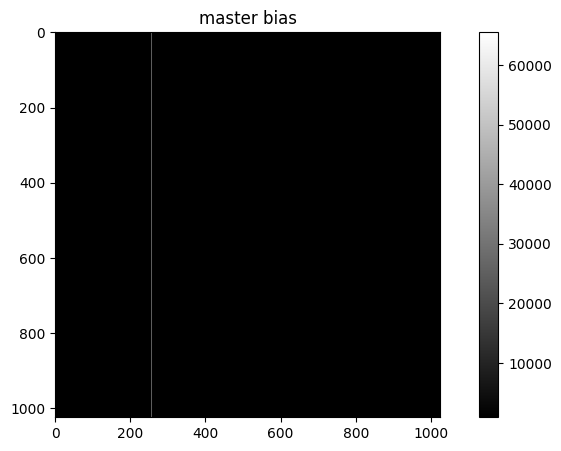

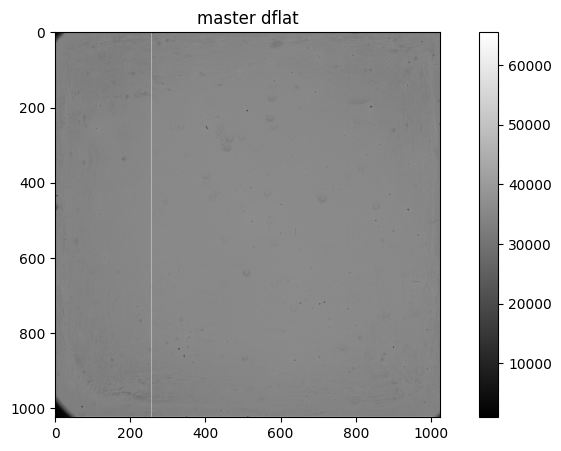

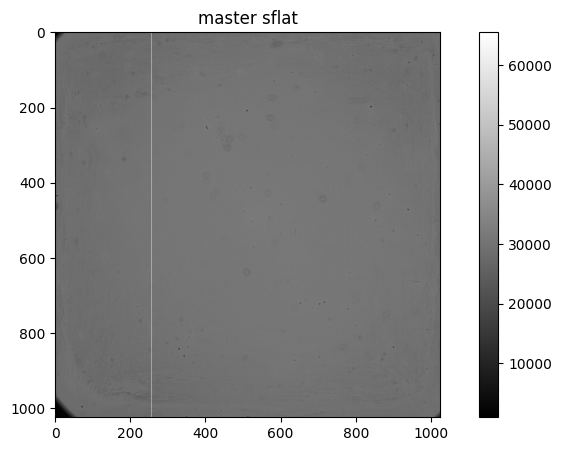

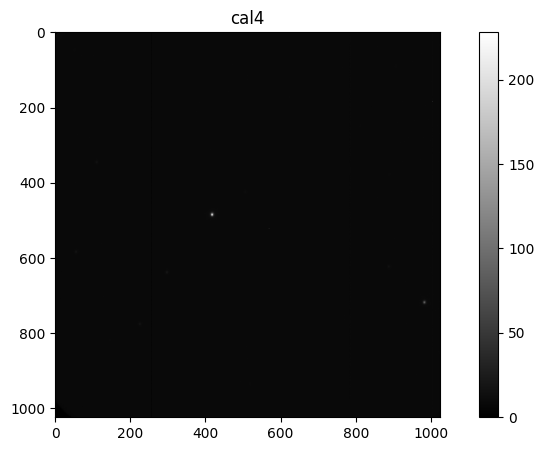

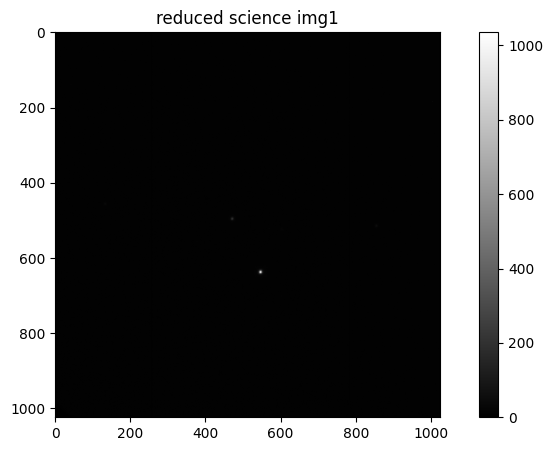

In [7]:
plt.figure("master bias", figsize=(10,5))
plt.imshow(bias[1],cmap="grey")
plt.title("master bias")
plt.colorbar()

plt.figure("master dflat", figsize=(10,5))
plt.imshow(dflat[1], cmap="grey")
plt.title('master dflat')
plt.colorbar()

plt.figure("master sflat", figsize=(10,5))
plt.imshow(sflat[1], cmap="grey")
plt.title('master sflat')
plt.colorbar()

plt.figure("cal4", figsize=(10,5))
plt.imshow(cal4[1],cmap="grey",vmin = 0, vmax=228)
plt.title('cal4')
plt.colorbar()

plt.figure("reduced science img1", figsize=(10,5))
plt.imshow(science_reduced[1][0], cmap="grey", vmin=0)
plt.title('reduced science img1')
plt.colorbar()

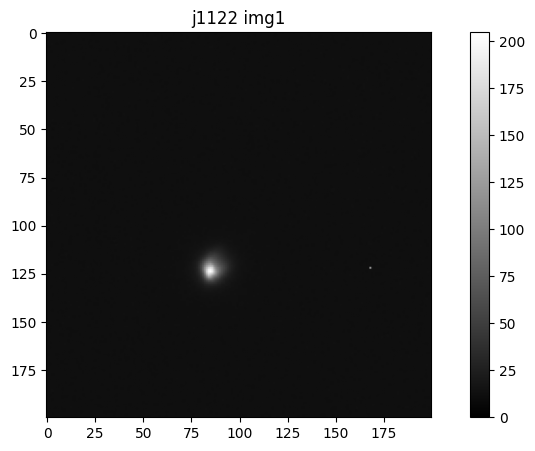

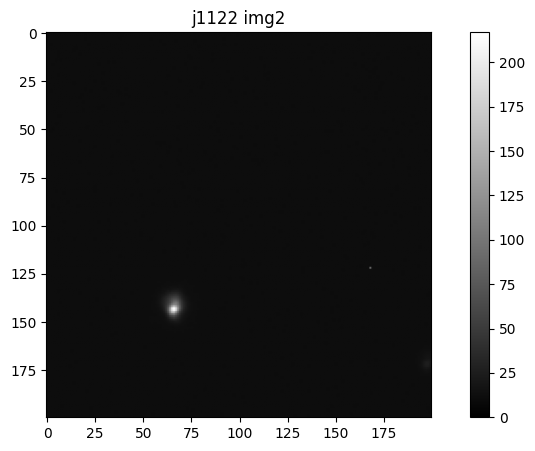

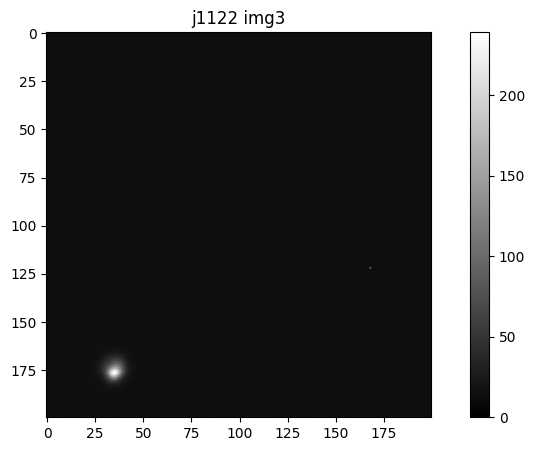

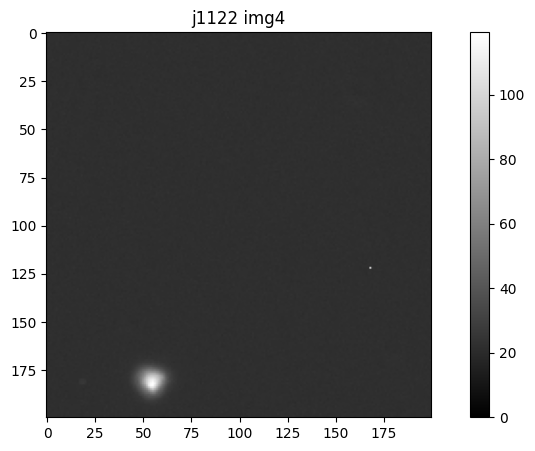

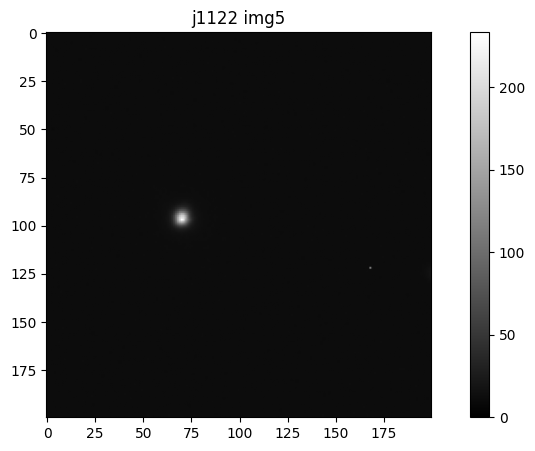

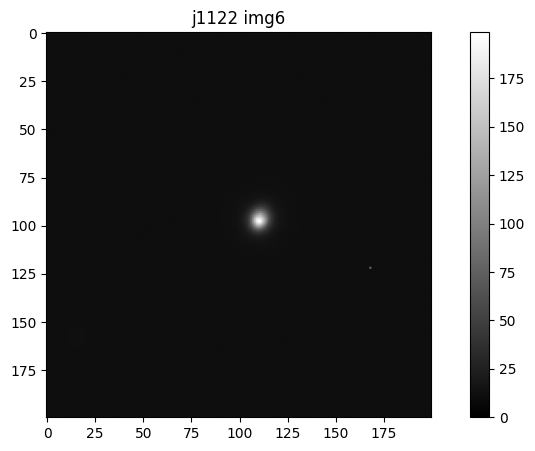

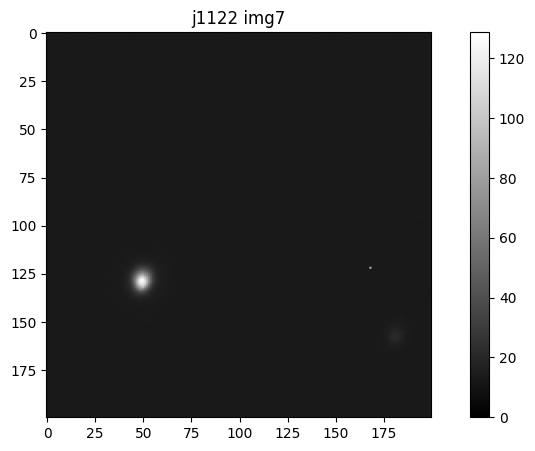

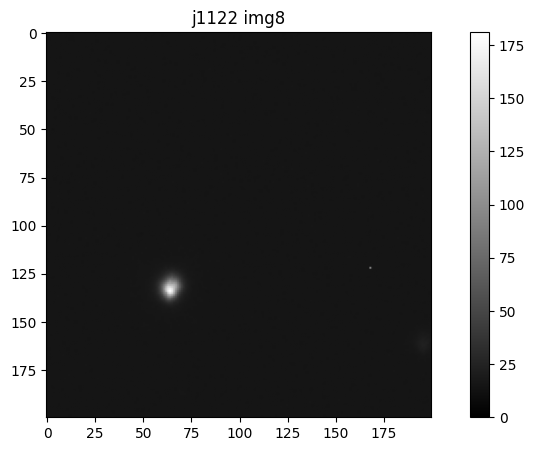

In [8]:
plt.figure("j1122 img1", figsize=(10,5))
plt.imshow(j1122[0], cmap="grey", vmin=0)
plt.title('j1122 img1')
plt.colorbar()

plt.figure("j1122 img2", figsize=(10,5))
plt.imshow(j1122[1], cmap="grey", vmin=0)
plt.title('j1122 img2')
plt.colorbar()

plt.figure("j1122 img3", figsize=(10,5))
plt.imshow(j1122[2], cmap="grey", vmin=0)
plt.title('j1122 img3')
plt.colorbar()

plt.figure("j1122 img4", figsize=(10,5))
plt.imshow(j1122[3], cmap="grey", vmin=0)
plt.title('j1122 img4')
plt.colorbar()

plt.figure("j1122 img5", figsize=(10,5))
plt.imshow(j1122[4], cmap="grey", vmin=0)
plt.title('j1122 img5')
plt.colorbar()

plt.figure("j1122 img6", figsize=(10,5))
plt.imshow(j1122[5], cmap="grey", vmin=0)
plt.title('j1122 img6')
plt.colorbar()

plt.figure("j1122 img7", figsize=(10,5))
plt.imshow(j1122[6], cmap="grey", vmin=0)
plt.title('j1122 img7')
plt.colorbar()

plt.figure("j1122 img8", figsize=(10,5))
plt.imshow(j1122[7], cmap="grey", vmin=0)
plt.title('j1122 img8')
plt.colorbar()

In [9]:
# function that finds the location of the max value in an array. useful for locating stars on an image with no other competing sources
# can specific row start/end and col start/end if you want to zoom in on a particular star manually (helpful if there are competing sources)
def find_max_location(array): 
    # gets the max value in the array
    max_index_flat = np.argmax(array)
    # unravels the array and locates index of the max value
    row_index, col_index = np.unravel_index(max_index_flat, array.shape)
    # returns coordinates of max value
    return row_index, col_index

# function that takes an array, a target location (usually provided by find max location) of an object
# and produces an array of 2R x 2R size centered on the object. can adjust R to encompass more or less of star
def slice_array(array, target, R):
    # turns target location into coords
    i, j = target
    # defining the edges of the box that will be cut out of the array, using radius requested in each direction
    row_start = i - R
    row_end   = i + R + 1   # +1 because the stop index for array slicing is exclusive
    col_start = j - R
    col_end   = j + R + 1

    # You might want to add error checking if your indices go out of bounds
    if row_start < 0 or col_start < 0 or row_end > array.shape[0] or col_end > array.shape[1]:
        raise ValueError("out of bounds")
    # returns sliced array
    return array[row_start:row_end, col_start:col_end]    

# function that takes in an array and a radius, and provides a sliced array around the star
def get_star(array, R):
    target = find_max_location(array)
    return(slice_array(array, target, R))

# function that takes in an array, a radius, and offset. provides a sliced array an offset away from the star (to get background)
def get_background(array, R, d):
    # locating star to base background off of
    i, j = find_max_location(array)
    # adding manual offset from star to get background
    i = i - d
    return(slice_array(array, (i,j), R))


Central Wavelength: 5369 Å


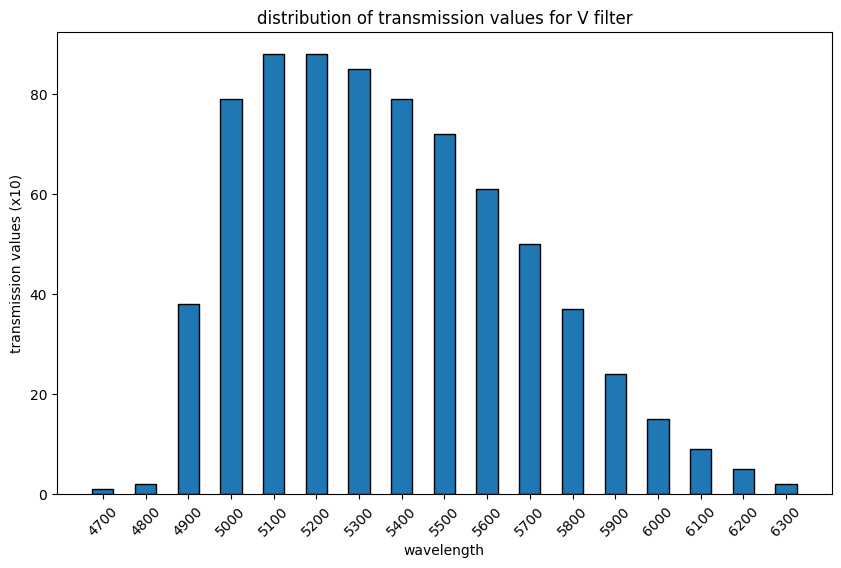

In [10]:
# from the lick website for V filter
wavelengths = [4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300]
transmissions = [0.01, 0.02, 0.38, 0.79, 0.88, 0.88, 0.85, 0.79, 0.72, 0.61, 0.50, 0.37, 0.24, 0.15, 0.09, 0.05, 0.02]
# for plotting on hist
counts = [1, 2, 38, 79, 88, 88, 85, 79, 72, 61, 50, 37, 24, 15, 9, 5, 2]

# weighted average of wavelengths
weighted_sum = sum(l * t for l, t in zip(wavelengths, transmissions))
# total transmission for calculating central wavelength
total_transmission = sum(transmissions)
# central wavelength calculation
central_wavelength = weighted_sum / total_transmission
print("Central Wavelength: {:.0f} Å".format(central_wavelength))

plt.figure(figsize=(10, 6))
plt.bar(wavelengths, counts, width=50, edgecolor='black')
plt.xlabel('wavelength')
plt.ylabel('transmission values (x10)')
plt.title('distribution of transmission values for V filter')
plt.xticks(wavelengths, rotation=45)
plt.show()


In [11]:
# calculating atm ext coef at lick
# assuming central wavelength of V band in johnson is 550nm
# 550nm does not exist in the lick table, so linearly interpolate from the two nearest measurements (526.3nm, 555.6nm)
k1 = [526.3,0.188]
k2 = [555.6,0.177]
# atm ext coef of 550nm at lick # dont assume 550 find from curve from webpage, then get extinction from linear interpolation, can use two points
# update: central wavelength from weighted average is 536.9
k = k1[1] + (536.9 - k1[0]) * (k2[1]-k1[1])/(k2[0]-k1[0])
#k_550 = k1[1] + (550 - k1[0]) * (k2[1]-k1[1])/(k2[0]-k1[0])

# finding interstellar dust of cal4
# paralax to KUV 11337+3946 (cal4) from simbad:
# 0.2555 [0.0311] A 2020yCat.1350....0G
# convert to distance
# 3914 +- 476 pc
# If you use, please cite Amôres et al. 2021, MNRAS, 508, 1788-1797. DOI: 10.1093/mnras/stab2248
# Model/map used: Amôres, E. B., & Lépine, J. R. D., 2005, AJ, 130, 659 - Considering fine-tuning for 120 deg <= l <= 200 deg (See paper Section 4.1) - ALA
# Extinction in A_V as provided by the authors.
# l, b, distance, A_V
# -------------------------------------------------
# 169.7583 70.1064 3.910 0.173
# -------------------------------------------------
cal_dust_ext = 0.173


# finding interstellar dust of J1122

# distance to J1122 found from simbad:
# | distance Q unit|  err-        err+     | method |     reference     |
# -----------------------------------------------------------------------
# |  257.646   pc  | -10.4750    +10.4750  |paral   |2020yCat.1350....0G|
#
# GALExtin result: f you use, please cite Amôres et al. 2021, MNRAS, 508, 1788-1797. DOI: 10.1093/mnras/stab2248 
# Model/map used: Amôres, E. B., & Lépine, J. R. D., 2005, AJ, 130, 659 - Considering fine-tuning for 120 deg <= l <= 200 deg (See paper Section 4.1) - ALA
# l, b, distance, A_V
# -------------------------------------------------
# 212.8492 69.9370 0.258 0.080
m_dust_ext= 0.08

average background count of cal4: 8.573703274977122 9.026126960924719


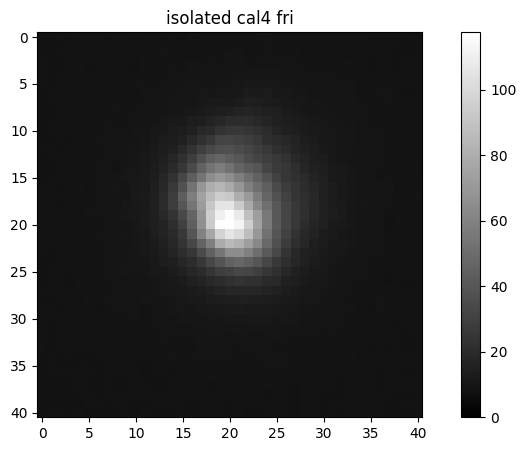

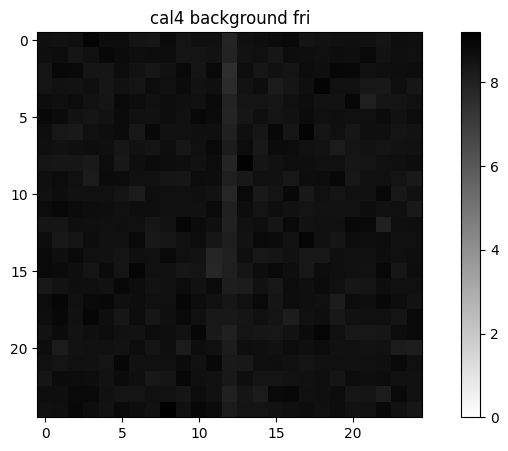

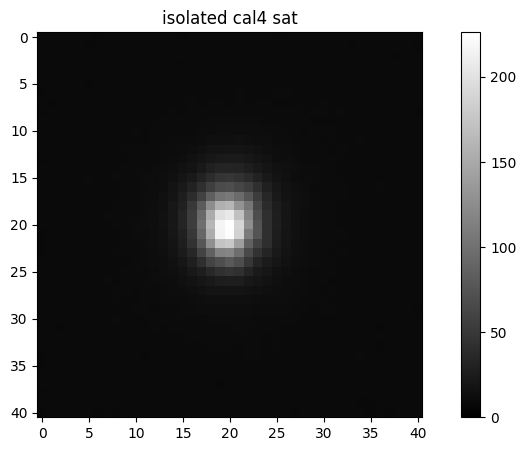

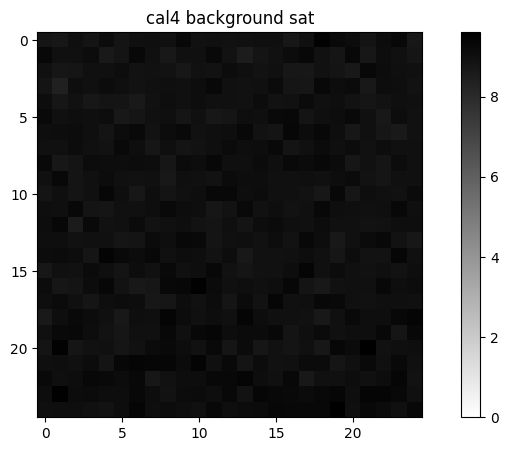

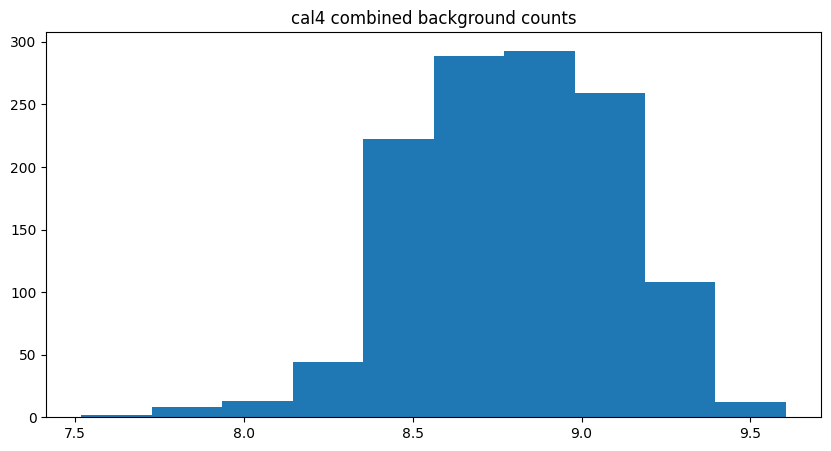

In [12]:
# printing sliced images
cal4_isolated = []
cal4_isolated.append(get_star(cal4[0][400:600, 400:600], 20))
cal4_isolated.append(get_star(cal4[1], 20))
plt.figure("isolated cal4 fri", figsize=(10,5))
plt.title("isolated cal4 fri")
plt.imshow(cal4_isolated[0], cmap="grey", vmin=0, vmax=np.max(cal4_isolated[0]))
plt.colorbar()

cal4_background = []
cal4_background.append(get_background(cal4[0], 12, 15))
cal4_background.append(get_background(cal4[1], 12, 30))
plt.figure("cal4 background fri", figsize=(10,5))
plt.title("cal4 background fri")
plt.imshow(cal4_background[0], cmap="grey_r", vmin=0) #, vmax=np.max(cal4_isolated)), toggle this if you want to see what background looks like in comparison. cmap is reversed grey so darker is brighter
plt.colorbar()

plt.figure("isolated cal4 sat", figsize=(10,5))
plt.title("isolated cal4 sat")
plt.imshow(cal4_isolated[1], cmap="grey", vmin=0, vmax=np.max(cal4_isolated[1]))
plt.colorbar()

plt.figure("cal4 background sat", figsize=(10,5))
plt.title("cal4 background sat")
plt.imshow(cal4_background[1], cmap="grey_r", vmin=0) #, vmax=np.max(cal4_isolated)), toggle this if you want to see what background looks like in comparison. cmap is reversed grey so darker is brighter
plt.colorbar()

cal4_ravel = np.ravel(np.concatenate((cal4_background[0], cal4_background[1])))
plt.figure("cal4 combined background counts", figsize=(10,5))
plt.hist(cal4_ravel)
plt.title("cal4 combined background counts")
plt.show

zp_background=[]
zp_background.append(np.mean(cal4_background[0]))
zp_background.append(np.mean(cal4_background[1]))
print("average background count of cal4:", zp_background[0], zp_background[1]) # using mean since no outliers

In [13]:
# 0 for saturday, 1 for friday
i = 1
ZP=[]
zp_err=[]
for i in range(2):
    # finding total counts in our calibration star
    total_counts = (sum(sum(cal4_isolated[i])))
    # finding background contribution, by multiplying avg background mag by the amount of pixels in aperture
    background_contribution = zp_background[i] * cal4_isolated[i].size
    # net counts is total counts from star minus the background counts
    net_counts = total_counts - background_contribution
    # known magnitude of our star in V
    m_known = 12.967
    # finding airmass
    cal_airmass = cal4_header[(i*4+2)]["AIRMASS"]
    # finding atmospheric extinction by multiplying the wavelegnth coef with the airmass
    cal_atm_ext = k *cal_airmass
    # calculation for zeropoint mag
    ZP.append(m_known +2.5*math.log10(net_counts) - cal_atm_ext - cal_dust_ext)
    print(f"zeropoint:{ZP[i]}")
    
    # error calcs
    # uncertainty in net counts (using total counts and backgroud)
    # poisson error
    total_counts_err = np.sqrt(total_counts + background_contribution)  
    # background error
    background_err = np.sqrt(zp_background[i] * cal4_isolated[i].size)  
    net_counts_err = np.sqrt(total_counts_err**2 + background_err**2)
    # error in the zeropoint from net counts
    zp_err.append( (2.5 / np.log(10)) * (net_counts_err / net_counts))
    print(f"zp_err: {zp_err[i]}")

zeropoint:22.573691186735395
zp_err: 0.02575954594369412
zeropoint:22.50918194907672
zp_err: 0.027720816037106393


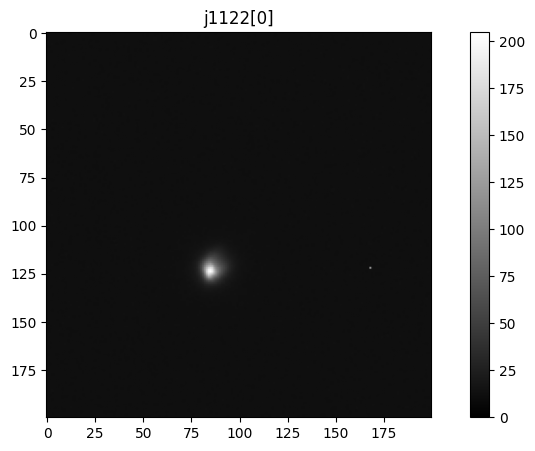

In [14]:
#plot of j1122 img, manually cut down to focus on our target
plt.figure("j1122[0]", figsize=(10,5))
plt.imshow(j1122[0], cmap="grey", vmin=0, vmax=np.max(j1122[0]))
plt.title("j1122[0]")
plt.colorbar()

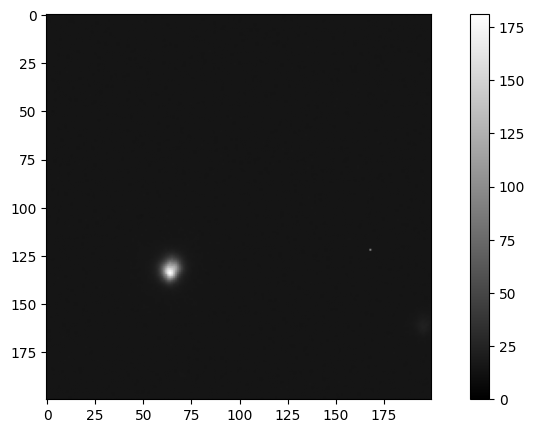

In [15]:
    plt.figure("j1122 star 8", figsize=(10,5))
    plt.imshow(j1122[7], cmap="grey", vmin=0)
    plt.colorbar()
    

In [16]:
# function to replcae outliers with median, only for use in 2 scenarios where a singular pixel in a background image had a massive number of counts
def replace_outliers(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    #find outliers
    outliers = np.abs(data - mean) > threshold * std
    #calculate value of non outlier median
    median_value = np.median(data[~outliers])
    # replace outliers with the median
    data[outliers] = median_value
    return data

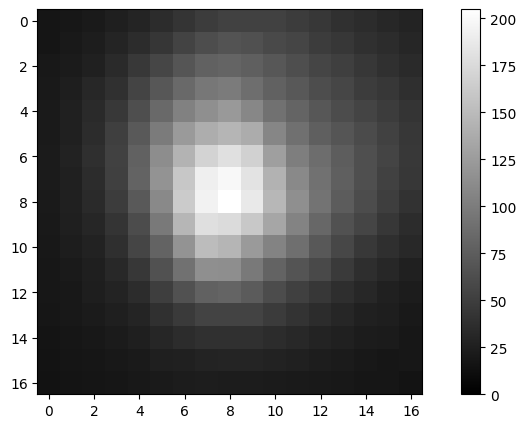

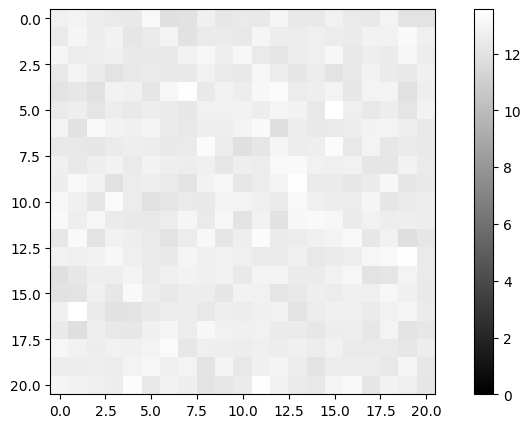

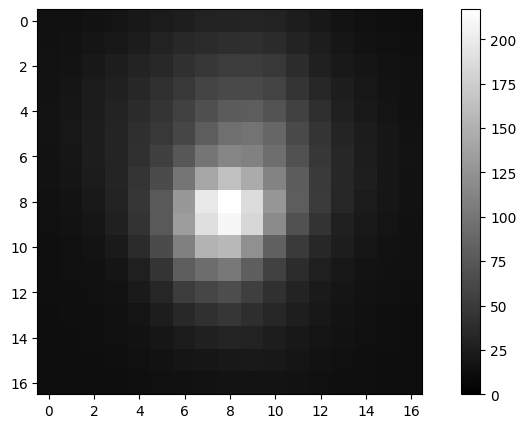

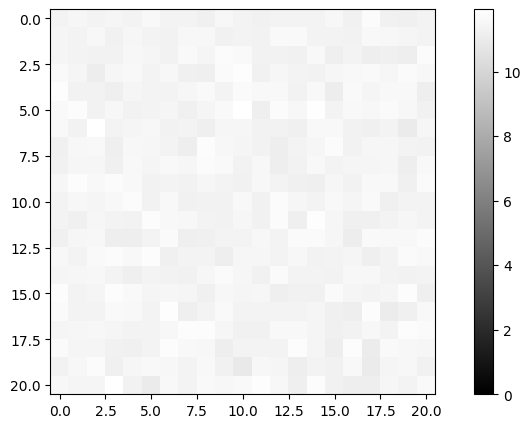

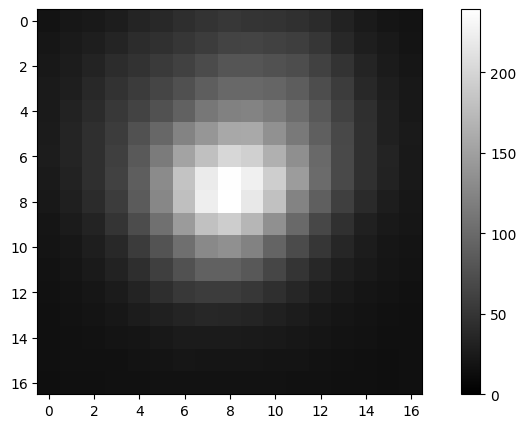

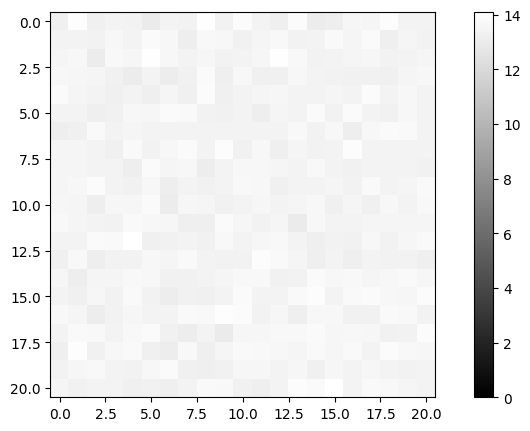

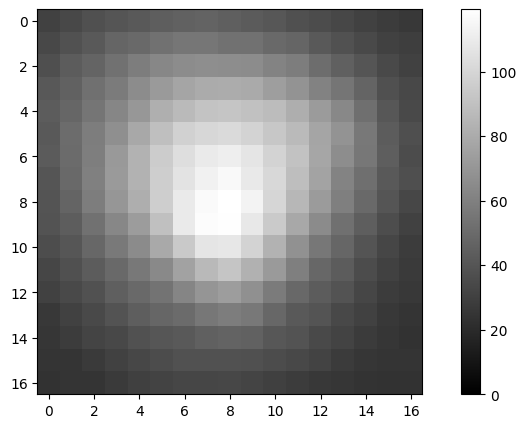

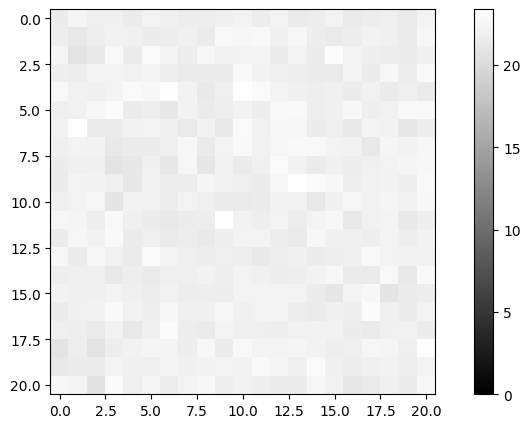

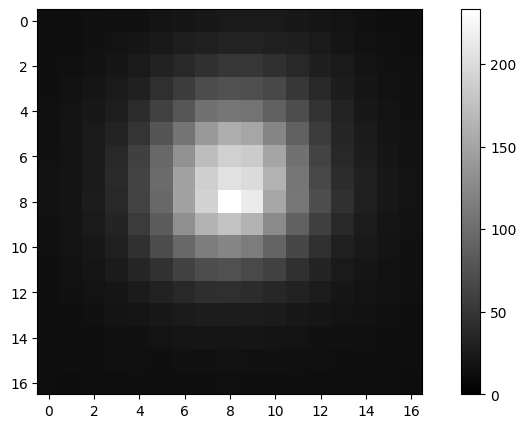

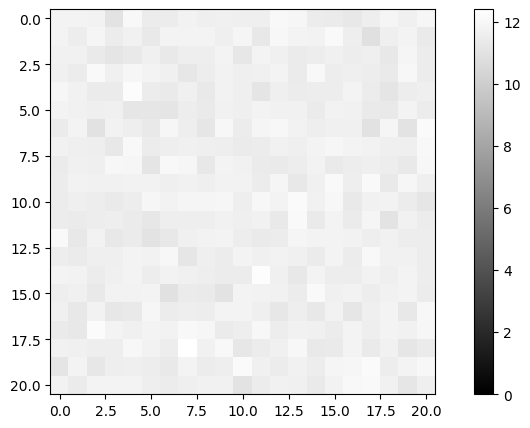

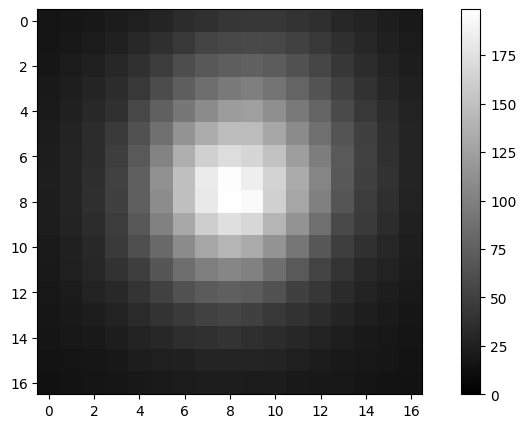

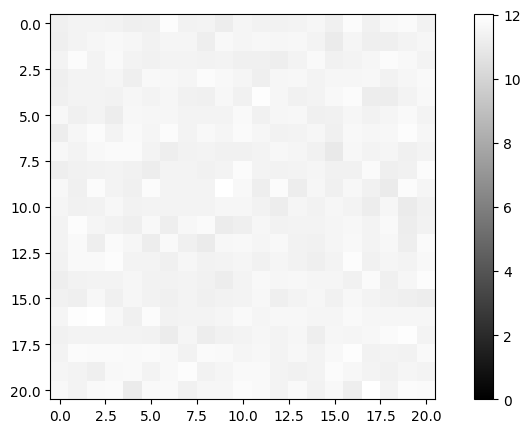

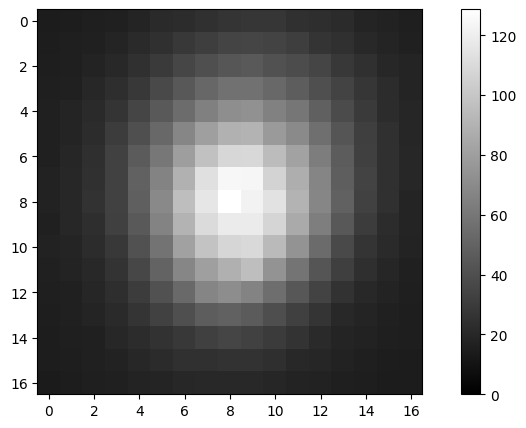

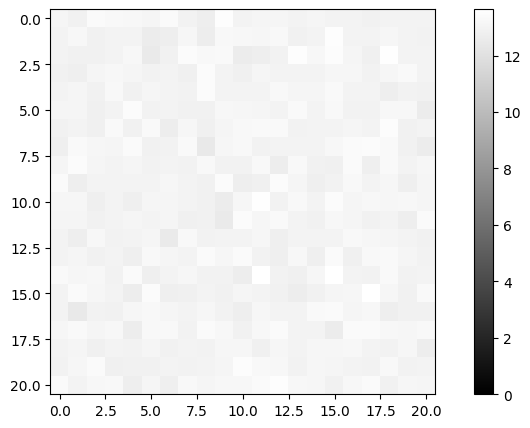

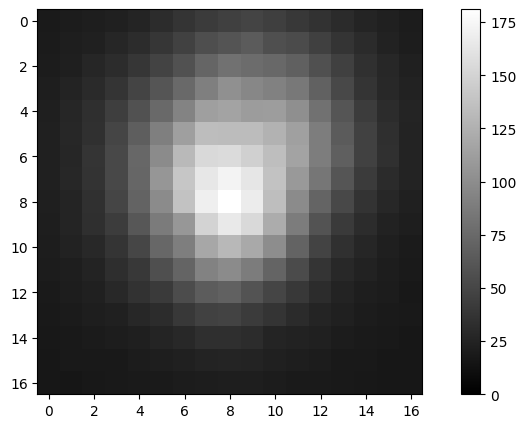

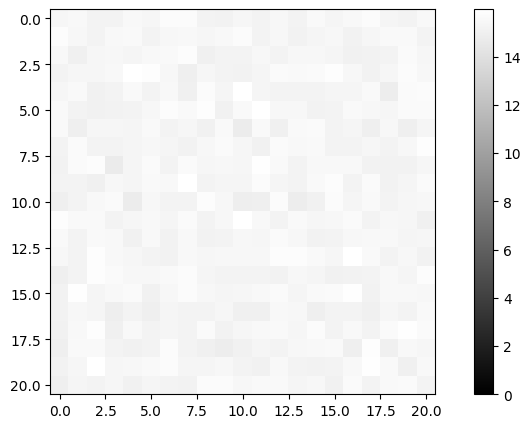

In [17]:
# explictly plotting all images of stars and background gotten from functions
# creating master star list and master background list, collection of "zoomed in" stars and their backgrounds
star_list = []
background_list = []

index=0
for i in j1122:
    # printing sliced images
    j1122_star = get_star(j1122[index], 8)
    j1122_background = get_background(j1122[index], 10, 40)
    star_list.append(j1122_star)
    background_list.append(replace_outliers(j1122_background))
    index=index+1
    
    plt.figure(f"j1122 star {index}", figsize=(10,5))
    plt.imshow(j1122_star, cmap="grey", vmin=0)
    plt.colorbar()
    plt.figure(f"testb{index}", figsize=(10,5))
    plt.imshow(j1122_background, cmap="grey", vmin=0) #, vmax=np.max(cal4_isolated)), toggle this if you want to see what background looks like in comparison. cmap is reversed grey so darker is brighter
    plt.colorbar()

In [18]:
# # creating master star list and master background list, collection of "zoomed in" stars and their backgrounds
# star_list = []
# background_list = []
# for img in j1122:
#     star_list.append(get_star(img, 10))
#     background_list.append(replace_outliers(get_background(img, 15, 40)))

background 1 count: 12.58599278687479
background 2 count: 11.439321556422286
background 3 count: 13.478636104982824
background 4 count: 21.982117945186722
background 5 count: 11.636382503116995
background 6 count: 11.48232367615722
background 7 count: 13.042503716968149
background 8 count: 15.37937494264941
average background count: 12.886714389115092


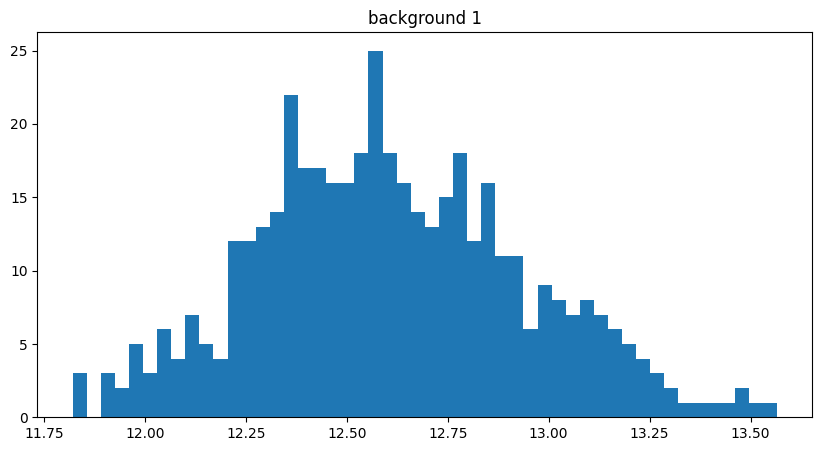

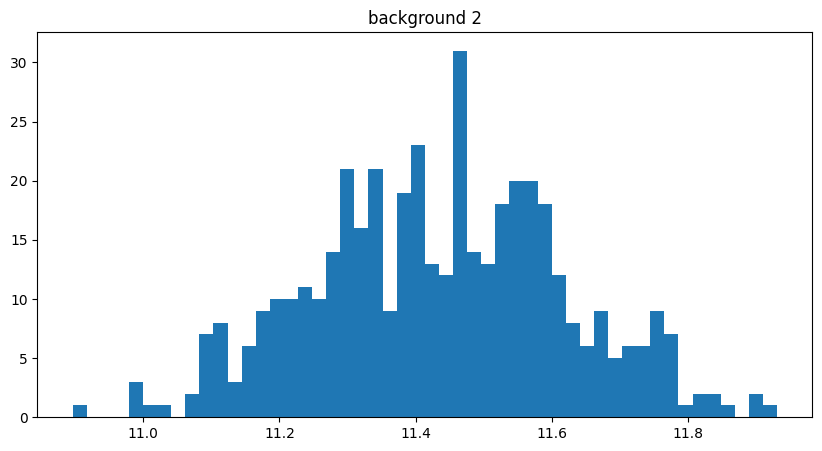

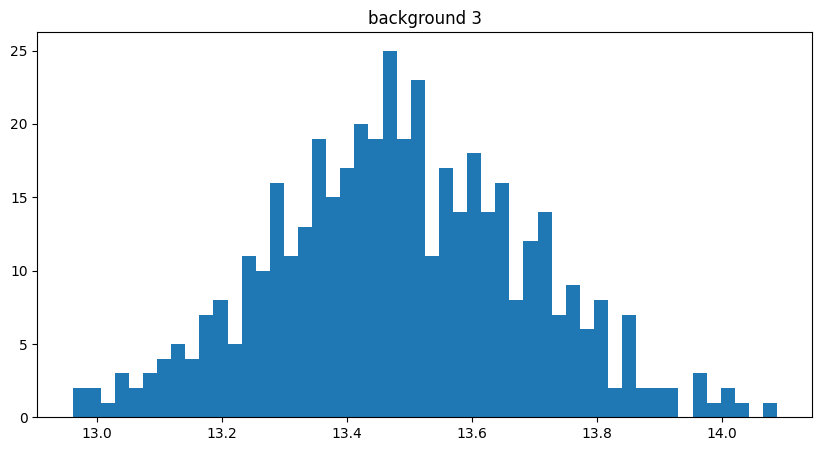

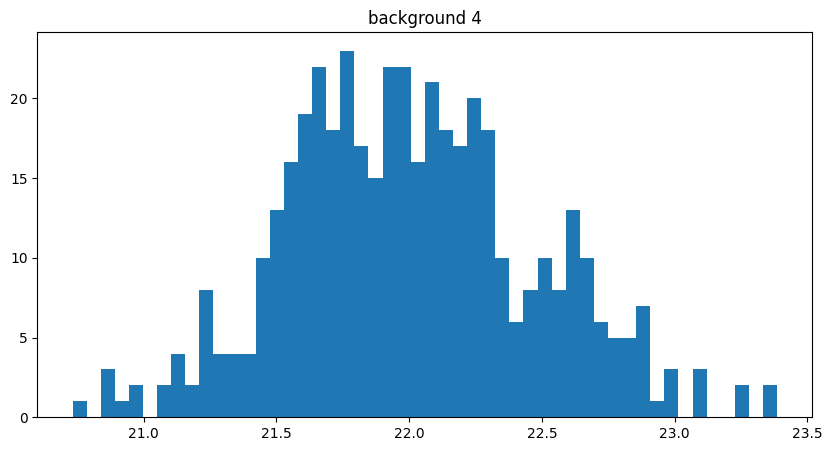

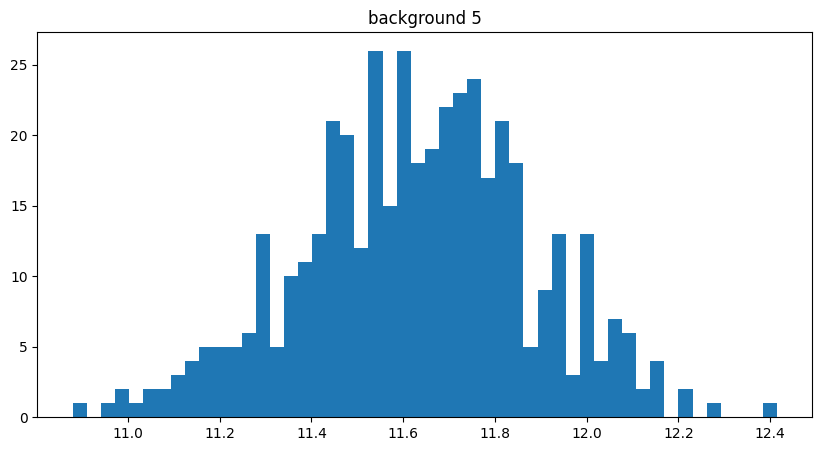

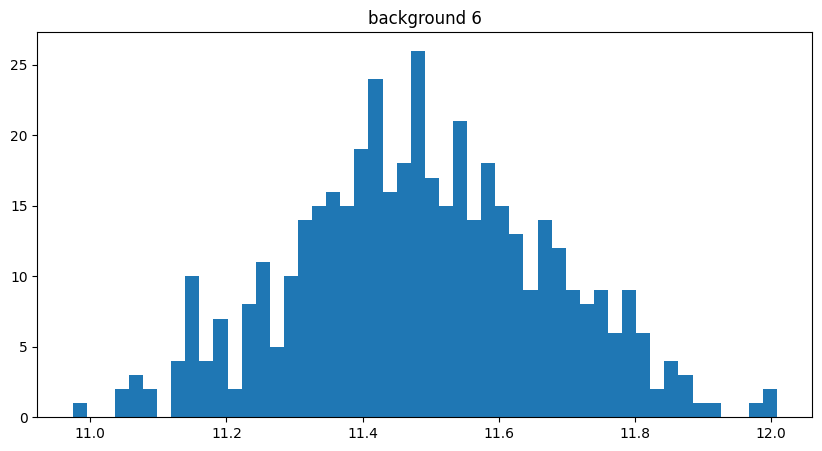

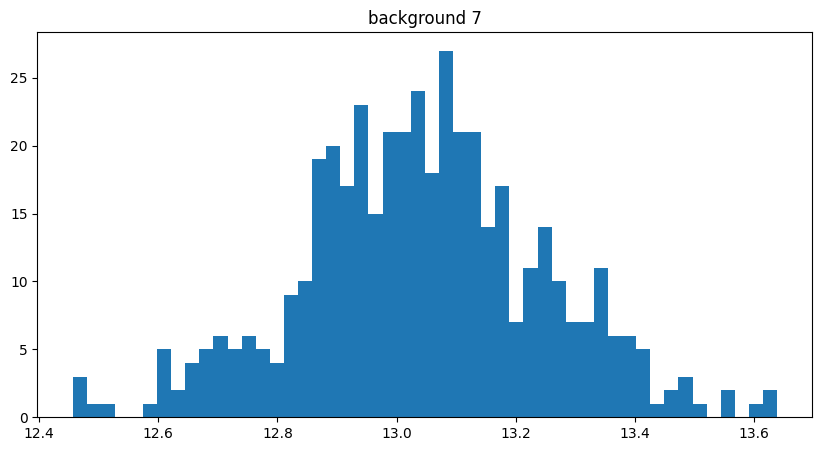

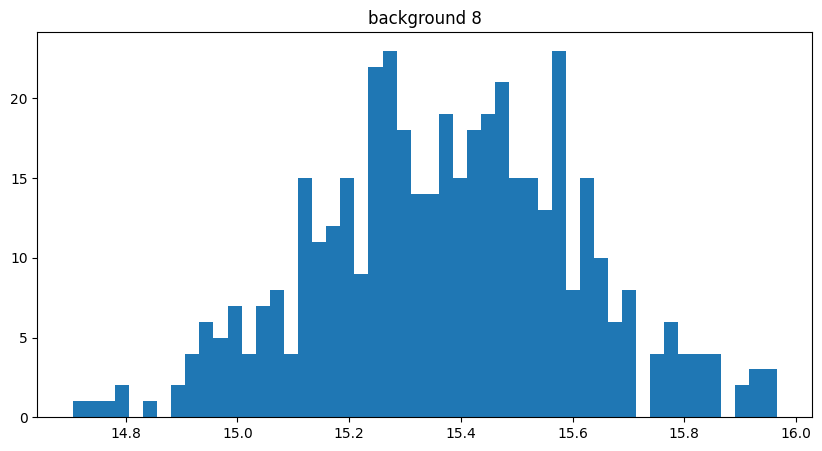

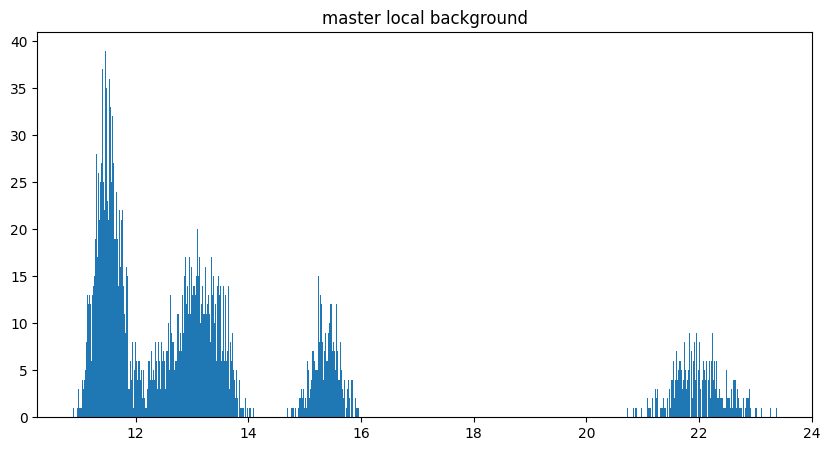

In [19]:
# adding all background lists together (from all 4 images) to plot together
index=0
master_background = []
avg_background = []
background_std = []
for i in background_list:
    # plot the background counts by raveling
    plt.figure(f"background {index+1}", figsize=(10,5))
    plt.hist(np.ravel(i),bins=50)
    plt.title(f"background {index+1}")
    # using the median as average since there are outliers
    print(f"background {index+1} count: {np.median(np.ravel(i))}")
    # add median counts to the list to use later
    avg_background.append(np.median(np.ravel(i)))
    background_std.append(np.std(i))
    # add counts to master background to plot all together
    master_background.extend(i)
    index = index+1

plt.figure("master local background", figsize=(10,5))
plt.hist(np.ravel(master_background), bins=1000)
plt.title("master local background")
plt.show

print("average background count:", np.median(np.ravel(master_background)))

In [20]:
# for some reason, when starting kernel and running all blocks, this doesnt run. make sure to run manually
time_pst = []
index = 0
# converting jy to erg/cm^2/s/Hz from caltech in V https://coolwiki.ipac.caltech.edu/index.php/Central_wavelengths_and_zero_points
#zero_point_flux = 3597.28 * 1e-23 
zero_point_flux = 3.63e-20
# create star dict to store each science image and associated info
star_dict = dict()
for i in star_list:
    # separating friday and saturday
    if index > 3:
        j=1 #for saturday
    else:
        j=0 # for friday
    # create new subdict for the particular image
    star_dict[index] = {}
    # get airmass from header
    airmass = sci_header_list[(index*5)+2]["AIRMASS"]
    # getting beginning time of 3rd exposure (avg time) of each sequence from the header 
    # sci_header_list where headers are stored, index*5+2 to go from header[2] -> header[7] -> header[12]
    # then, converting to jd time by using astropy time package. dates stored in isot
    time = Time(sci_header_list[(index*5)+2]["DATE-BEG"], format="isot", scale="local").jd
    # get total counts of the image. need to sum all rows and then all columns
    counts = sum(sum(i))
    # get background counts from the list earlier. index number should align with the image, more background counts in later images
    background_counts = avg_background[index]
    # subtract background counts from observed counts to get net counts
    net_counts = counts-background_counts

    # atm ext calculated from measured k value times airmass of each object. k calculation earlier in notebook
    m_atm_ext = k * airmass


    # final magnitude calculation
    m_I = -2.5 * math.log10(net_counts) - m_atm_ext - m_dust_ext + ZP[j]

    # propogating error to mag (from background):
    pixels = i.size
    b_std = background_std[index]
    counts_err = np.sqrt(net_counts * pixels * (b_std)**2)
    mag_err_no_zp = (2.5/np.log(10)) * counts_err/net_counts
    mag_err = np.sqrt(mag_err_no_zp**2 + zp_err[j]**2)
    # flux calculation ------------------------------------------------------------------------
    flux = 10**(-0.4 * m_I) * zero_point_flux
    # propogating error to flux
    flux_err = 0.4*np.log(10)*flux*mag_err
    
    # add all quantities to the dict before moving to next image. reference later for light curve or if necessary
    #star_dict[index]["airmass"] = airmass # decided i dont need to save airmass after ext calculated
    star_dict[index]["mag"] = m_I
    star_dict[index]["time"] = time
    star_dict[index]["mag_err"] = mag_err
    star_dict[index]["flux"] = flux
    star_dict[index]["flux_err"] = flux_err

    # only 7 images, so make sure it only iterates 7 times
    if index < 7:
        index=index+1
    else:
        break

In [21]:
# turning the dict into a table for printing
j1122_df = pd.DataFrame(star_dict)
# to ensure information isnt lost
pd.set_option("display.precision", 15)
j1122_df = j1122_df.reindex(["time", "mag", "mag_err", "flux", "flux_err"])
j1122_df = j1122_df.T
print(j1122_df)
j1122_df.to_csv("j1122_observations.csv", float_format="%.40e")

                    time                 mag            mag_err  \
0  2.460777736552315e+06  11.743730618682124  0.053975812128286   
1  2.460777798857871e+06  12.177834216700388  0.041176876867041   
2  2.460777845737963e+06  11.755918241533305  0.039445227638003   
3  2.460777880158912e+06  11.749464418575419  0.072619616405305   
4  2.460778725197107e+06  11.997019639409739  0.050027976980940   
5  2.460778807600231e+06  11.715826854365327  0.038749563696286   
6  2.460778853734722e+06  12.080108035474055  0.045122375205161   
7  2.460778887643056e+06  11.745688549882450  0.045075270912843   

                    flux               flux_err  
0  7.284745394527833e-25  3.621506283886167e-26  
1  4.883969446122094e-25  1.852260315388124e-26  
2  7.203429804129415e-25  2.617034664157279e-26  
3  7.246375877331730e-25  4.846748540154978e-26  
4  5.768976492224213e-25  2.658198390104082e-26  
5  7.474392211425194e-25  2.667585697321041e-26  
6  5.343962609854633e-25  2.220910428403081e-2

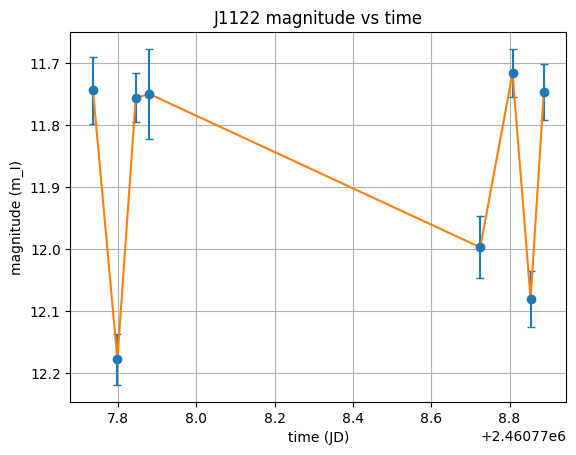

In [22]:
index=0
# mag and time lists to plot against eachother
time_list=[]
mag_list=[]
mag_err_list=[]
flux_list=[]
flux_err_list=[]

# iterating through the dict, grabbing the magnitudes, times, and errors
for index in range(len(star_dict)):
    mag_list.append(star_dict[index]["mag"])
    time_list.append(star_dict[index]["time"])
    mag_err_list.append(star_dict[index]["mag_err"])
    flux_list.append(star_dict[index]["flux"])
    flux_err_list.append(star_dict[index]["flux_err"])

# plot mags vs times
plt.figure("J1122 magnitude vs time")
plt.title("J1122 magnitude vs time")
plt.ylabel("magnitude (m_I)")
plt.xlabel("time (JD)")
plt.gca().invert_yaxis() 
plt.errorbar(time_list, mag_list, yerr=mag_err_list, fmt='o', capsize=3)
plt.grid(True)
plt.plot(time_list, mag_list)
plt.savefig("j1122_mag_versus_time.png")
plt.show()

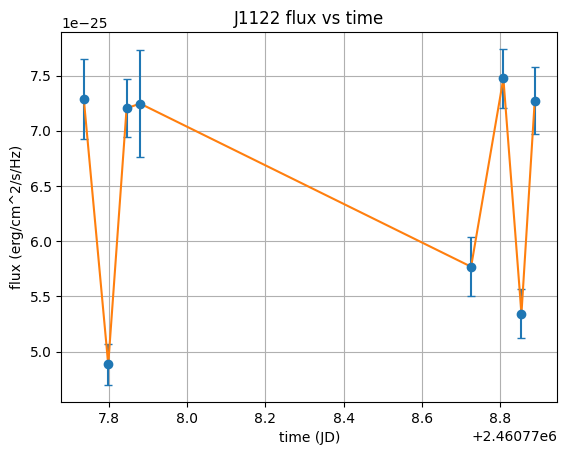

flux amplitude is 2.5904227653031e-25


In [23]:
# plot flux vs times
plt.figure("J1122 flux vs time")
plt.title("J1122 flux vs time")
plt.ylabel("flux (erg/cm^2/s/Hz)")
plt.xlabel("time (JD)")
plt.errorbar(time_list, flux_list, yerr=flux_err_list, fmt='o', capsize=3)
plt.grid(True)
plt.plot(time_list, flux_list)
plt.savefig("j1122_flux_versus_time.png")
plt.show()

flux_amp = (max(flux_list)-min(flux_list))
print(f"flux amplitude is {flux_amp}")

Maximum rate of flux change = 3.44e-25 (flux unit/hour) at time = 27.626 hour


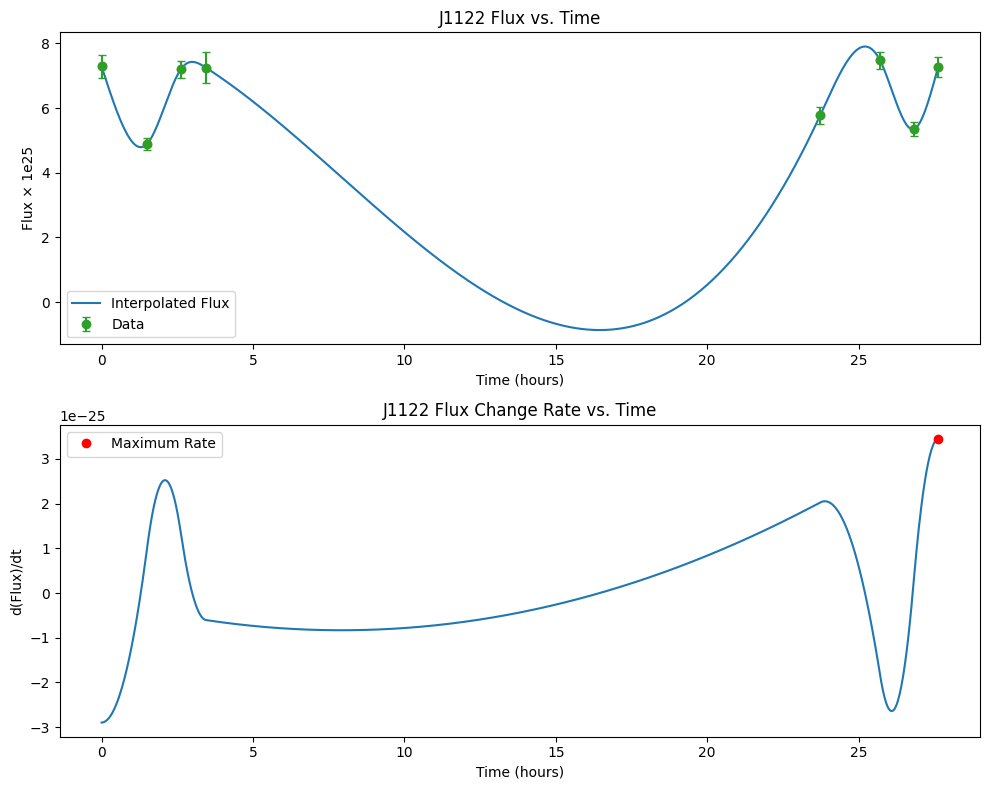

In [24]:
# convert time from JD to hours, normalize by subtracting the starting JD time from each time measurment in the list, and then multiply by 24 to get hour
time = np.array((time_list - time_list[0])*24)
fluxes = np.array(flux_list)
fluxes_err = np.array(flux_err_list)
# scale fluxes so that the derivatives look better
scale_factor = 1e25
scaled_fluxes = fluxes * scale_factor
scaled_fluxes_err = fluxes_err * scale_factor
# interp derivative is scaled in scaled flux-unit/hour. multiply by 1/scale_factor to get back to original units.
use_scaling = True
# scaling fluxes
if use_scaling:
    y = scaled_fluxes
    flux_unit_str = "flux×1e-25 unit"
else:
    y = fluxes
    flux_unit_str = "flux unit"
# create the cubic spline interpolation, looks best compared to standard cubic polynomial
cs = CubicSpline(time, y, bc_type='natural')
# time grid to interpolate over
t_fine = np.linspace((time.min()), (time.max()), 1000)
flux_interp = cs(t_fine)
flux_rate = cs.derivative()(t_fine)
# scaling back to unscaled flux rate if scaled, and left alone if not scaled
if use_scaling:
    flux_rate_original = flux_rate / scale_factor
else:
    flux_rate_original = flux_rate
# finding max abs derivative value
max_rate_index = np.argmax(np.abs(flux_rate))
max_rate = flux_rate_original[max_rate_index]
max_rate_time = t_fine[max_rate_index]
print("Maximum rate of flux change = {:.2e} (flux unit/hour) at time = {:.3f} hour".format(max_rate, max_rate_time))

# plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# plot flux vs time with fitted line. makes sure to include info that is scaled if scaling is used
if use_scaling:
    ax[0].plot(t_fine, cs(t_fine), label='Interpolated Flux')
    ax[0].plot(time, scaled_fluxes, 'o')
    ax[0].errorbar(time, scaled_fluxes, yerr=scaled_fluxes_err, fmt='o', capsize=3,label='Data')
    ax[0].set_ylabel("Flux × 1e25")
else:
    ax[0].plot(t_fine, cs(t_fine), label='Interpolated Flux')
    ax[0].plot(time, fluxes, 'o', label='Data')
    ax[0].errorbar(time, fluxes, yerr=fluxes_err, fmt='o', capsize=3, label='Data')
    ax[0].set_ylabel("Flux")
    
ax[0].set_title("J1122 Flux vs. Time")
ax[0].set_xlabel("Time (hours)")
ax[0].legend()

# plot derivatives
ax[1].plot(t_fine, flux_rate_original) #, label='Flux Change Rate (original flux units/hour)'
ax[1].plot(max_rate_time, max_rate, 'ro', label="Maximum Rate")
ax[1].set_title("J1122 Flux Change Rate vs. Time")
ax[1].set_xlabel("Time (hours)")
ax[1].set_ylabel("d(Flux)/dt")
ax[1].legend()

plt.tight_layout()
plt.savefig("j1122_lightcurve.png")
plt.show()


In [25]:
from astropy.timeseries import LombScargle
import numpy as np

# time in days, flux or mag in linear arrays
frequency, power = LombScargle(time, fluxes).autopower()
best_period = 1 / frequency[np.argmax(power)]

print(best_period)


2.790523007737868


In [26]:
period_2 = best_period*2
print(period_2)

5.581046015475736


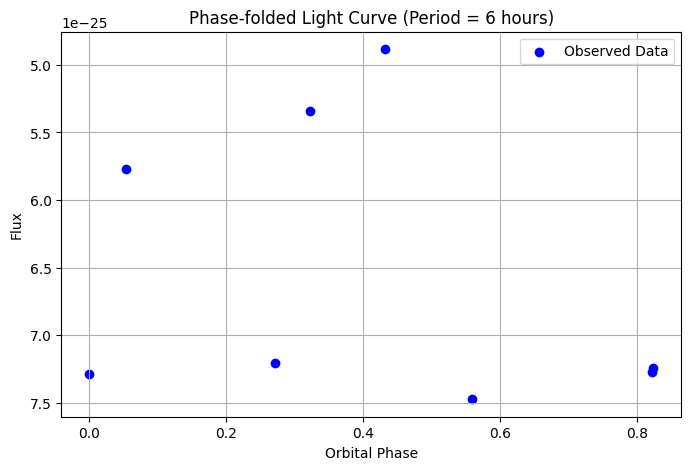

In [27]:
flux = fluxes
period = 0.2325# days (5.8 hrs)
#period = 0.26#$ 6.24 hrs
# phase folding
time0 = time[0]  # or you can choose some reference time
phase = ((time - time0) % period) / period

# sort by phase
sorted_indices = np.argsort(phase)
phase_sorted = phase[sorted_indices]
flux_sorted = flux[sorted_indices]

# plotting
plt.figure(figsize=(8,5))
plt.scatter(phase_sorted, flux_sorted, color='blue', label='Observed Data')
plt.xlabel('Orbital Phase')
plt.ylabel('Flux')
plt.title('Phase-folded Light Curve (Period = 6 hours)')
plt.gca().invert_yaxis()  # optional: lower flux = eclipse
plt.legend()
plt.grid(True)
plt.show()


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# gaussian dip function
def double_gaussian_dip(t, F0, dF1, t1, sigma1, dF2, t2, sigma2, dF3, t3, sigma3):
    return (F0 
            - dF1 * np.exp(-0.5 * ((t - t1) / sigma1) ** 2)
            - dF2 * np.exp(-0.5 * ((t - t2) / sigma2) ** 2)
            - dF3 * np.exp(-0.5 * ((t - t3) / sigma3) ** 2))


# to plot flux
# t_data = phase_sorted
# flux_data = flux_sorted
# initial_guess = [7.5e-25, 2.1e-25, 0.25, 0.05, 2.1e-25,1,0.05]
# lower_bounds = [
#     7.0e-25,     # F0 
#     1e-25,    # dF1 
#     0.20,    # t1 
#     0.01,    # sigma1 
#     1e-25,    # dF2
#     0.85,    # t2 
#     0.01     # sigma2 
# ]
# upper_bounds = [
#     7.5e-25,     # F0
#     3e-25,     # dF1
#     0.30,    # t1 
#     0.06,    # sigma1
#     4e-25,    # dF2 
#     1.2,    # t2 
#     0.06      # sigma2 
# ]


t_data = time
flux_data = fluxes
# parameters: [F0, dF1, t1, sigma1, dF2, t2, sigma2]
initial_guess = [7.5e-25, 2.3e-25, 1.495, 0.5, 0.8e-25, 23.7, 0.5,1.4e-25,26.8,0.5]
lower_bounds = [
    7.0e-25,     # F0 
    1e-25,    # dF1 
    0,    # t1 
    0.01,    # sigma1 
    0.2e-25,    # dF2
    22,    # t2
    0.01,     # sigma2
    0.2e-25,    # dF3
    25,    # t3
    0.01     # sigma3
]
upper_bounds = [
    7.5e-25,     # F0
    4e-25,     # dF1
    3,    # t1
    1,    # sigma1 
    3e-25,    # dF2 
    25,    # t2 
    1,      # sigma2 
    4e-25,    # dF3
    30,    # t3
    1      # sigma3
]
# fit model
popt, pcov = curve_fit(double_gaussian_dip, t_data, flux_data, p0=initial_guess, bounds=(lower_bounds, upper_bounds))
F0_fit, dF1_fit, t1_fit, sigma1_fit, dF2_fit, t2_fit, sigma2_fit,dF3_fit, t3_fit, sigma3_fit = popt
# generate fitted flux values for plotting
t_fit = np.linspace(min(t_data), max(t_data), 500)
flux_fit = double_gaussian_dip(t_fit, *popt)

# plot data and fit


# ------------------------------------------------ old plot, uncomment if you want to see
# plt.figure(figsize=(8, 5))
# plt.plot(t_data, flux_data, 'o', label='Data')
# plt.plot(t_fit, flux_fit, '-', label='Double Gaussian Dip Fit')
# plt.errorbar(t_data, flux_data, yerr=fluxes_err, fmt='o', capsize=3, label='Data')
# plt.xlabel('Time')
# plt.ylabel('Flux')
# plt.title('Eclipsing Binary Light Curve with Two Gaussian Dips')
# plt.legend()
# plt.show()

# print params
# print("Fitted parameters:")
# print("F0 (baseline) =", F0_fit)
# print("dF1 (depth of first dip) =", dF1_fit)
# print("t1 (center of first dip) =", t1_fit)
# print("sigma1 (width of first dip) =", sigma1_fit)
# print("dF2 (depth of second dip) =", dF2_fit)
# print("t2 (center of second dip) =", t2_fit)
# print("sigma2 (width of second dip) =", sigma2_fit)
# print("dF3 (depth of second dip) =", dF3_fit)
# print("t3 (center of second dip) =", t3_fit)
# print("sigma3 (width of second dip) =", sigma3_fit)


/tmp/ipykernel_3336/2174375686.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(double_gaussian_dip, t_data, flux_data, p0=initial_guess, bounds=(lower_bounds, upper_bounds))


use the found period (5.7?) double check the famplitude to make sure it makes sense with the target. extrapolate the curve to fit every 6 hours instead of just a straight line.

Single-dip fit:
 F0 = 7.315e-25,  depth = 2.518e-25,  t0 = 1.497 h,  σ = 0.205 h


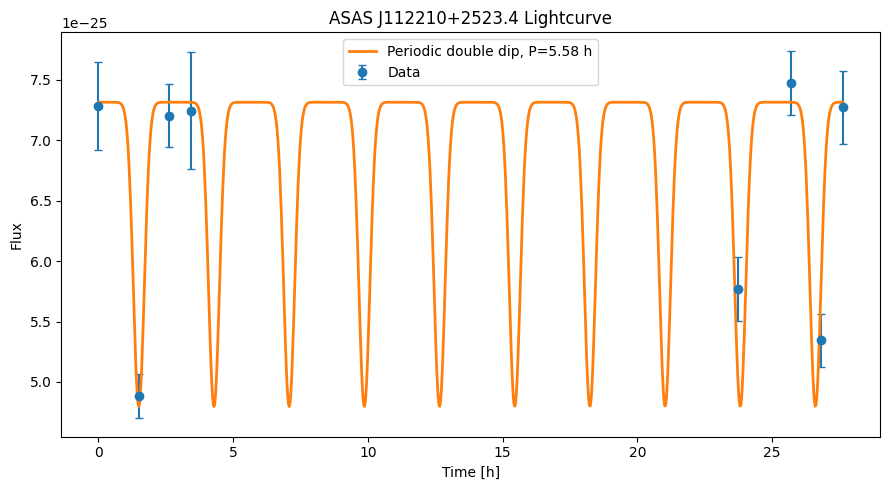

In [46]:
# single guass dip fn-
def single_gauss_dip(t, F0, dF, t0, sigma):
    """A baseline F0 minus a single Gaussian dip of depth dF, center t0, width sigma."""
    return F0 - dF * np.exp(-0.5 * ((t - t0) / sigma)**2)
# period version to propogate after finding single dip
def periodic_gauss_dip(t, F0, dF, t0, sigma, P):
    """
    Sum the same Gaussian dip every P hours.
    We tile k from k_min to k_max so that (t0 + k*P) covers the range of t.
    """
    # determine how many cycles are needed to cover your t-range
    k_min = int(np.floor((t.min() - t0) / P))
    k_max = int(np.ceil((t.max() - t0) / P))
    out = np.zeros_like(t) + F0
    for k in range(k_min, k_max + 1):
        out -= dF * np.exp(-0.5 * ((t - (t0 + k * P)) / sigma)**2)
    return out
# fit one dip to get best params
t_data  = np.array([ 0.       ,  1.4953333,  2.6204556,  3.4465583,
                    23.727475 , 25.70515  , 26.8123778, 27.6261778])
flux_data = np.array([7.28474539e-25, 4.88396945e-25, 7.20342980e-25,
                      7.24637588e-25, 5.76897649e-25, 7.47439221e-25,
                      5.34396261e-25, 7.27162050e-25])

# initial guess: [F0, depth, t0, width]
p0 = [7.5e-25, 2.0e-25, 1.5, 0.2]
bounds = ([7.3e-25, 0,    1.0, 0.01],   # lower: F0, no negative depth, t0 ~1.0
          [8.0e-25, 5e-25, 2.0, 0.7 ])   # upper: F0, depth, t0 ~2.0

popt, pcov = curve_fit(single_gauss_dip, t_data, flux_data,
                       sigma=flux_err_list, p0=p0, bounds=bounds)

F0_fit, dF_fit, t0_fit, sigma_fit = popt
print("Single-dip fit:")
print(f" F0 = {F0_fit:.3e},  depth = {dF_fit:.3e},  t0 = {t0_fit:.3f} h,  σ = {sigma_fit:.3f} h")

# generate grid and evaluate model
#P = 3.12  # hours
P = best_period
t_grid = np.linspace(t_data.min(), t_data.max(), 1000)
flux_model = periodic_gauss_dip(t_grid, F0_fit, dF_fit, t0_fit, sigma_fit, P)
#plot
plt.figure(figsize=(9,5))
plt.errorbar(t_data, flux_data, yerr=flux_err_list, fmt='o', capsize=3, label='Data')
plt.plot(t_grid, flux_model, '-', lw=2, label=f'Periodic double dip, P={period_2:.2f} h')
plt.xlabel('Time [h]')
plt.ylabel('Flux')
plt.title('ASAS J112210+2523.4 Lightcurve')
plt.legend()
plt.tight_layout()
plt.savefig("J1122LC_final.png")
plt.show()


In [44]:
def d_periodic_gauss_dip(t, dF, t0, sigma, P):
    """Derivative of one repeated Gaussian dip at t0 with depth dF, width sigma."""
    k_min = int(np.floor((t.min() - t0) / P))
    k_max = int(np.ceil((t.max() - t0) / P))
    deriv = np.zeros_like(t)
    for k in range(k_min, k_max + 1):
        dt = t - (t0 + k*P)
        gauss = np.exp(-0.5*(dt/sigma)**2)
        # each contributes dF * (dt/sigma^2) * exp(...)
        deriv += dF * (dt / sigma**2) * gauss
    return deriv

# If you fit only one dip and tile it:
dFdt_grid = d_periodic_gauss_dip(t_grid, dF_fit, t0_fit, sigma_fit, P)

t_star=10
# To get it at a single t*:
dFdt_at_tstar = d_periodic_gauss_dip(np.array([t_star],dtype=float), dF_fit, t0_fit, sigma_fit, P)[0]
print("Analytic dF/dt @", t_star, "h =", dFdt_at_tstar)


Analytic dF/dt @ 10 h = 6.425390208082317e-25


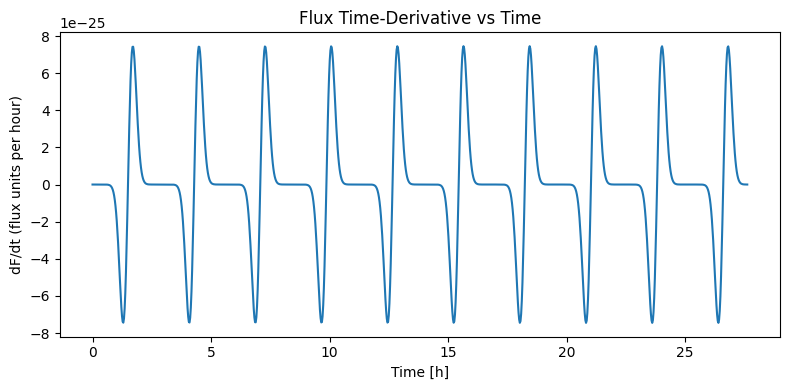

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(t_grid, dFdt_grid, '-')
plt.xlabel('Time [h]')
plt.ylabel('dF/dt (flux units per hour)')
plt.title('Flux Time-Derivative vs Time')
plt.tight_layout()
plt.savefig("J1122_dF_dt.png")
plt.show()


In [47]:
# index of the maximum derivative
i_max = np.argmax(dFdt_grid)
# peak value and its time
peak_slope = dFdt_grid[i_max]
t_peak      = t_grid[i_max]

print(f"Peak dF/dt = {peak_slope:.3e} flux units/hour at t = {t_peak:.3f} h")


Peak dF/dt = 7.454e-25 flux units/hour at t = 18.445 h
